###Importing libraries

In [48]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 

In [49]:
df = pd.read_csv('my_data.csv')
df.head(5)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165000,137000,472000,New York,209200
1,160000,151000,445000,California,202800
2,155000,102000,420000,Florida,197300
3,150000,119000,400000,New York,191900
4,145000,92000,385000,Florida,185300


In [50]:
X = df.iloc[:, :-1]
y = df.iloc[:,-1]

In [51]:
y

0     209200
1     202800
2     197300
3     191900
4     185300
5     180000
6     174600
7     169600
8     165400
9     160000
10    155100
11    150000
12    145600
13    141300
14    137500
15    132900
16    128800
17    124700
18    120500
19    116800
20    113900
21    111300
22    108600
23    106000
24    103100
25    100600
26     97900
27     95200
28     92800
29     90100
30     87800
31     85200
32     82900
33     80500
34     78200
35     75900
36     73600
37     71200
38     69000
39     66600
40     64200
41     62000
42     59600
43     57300
44     54900
45     52600
46     50200
47     47800
48     45400
49     43100
Name: Profit, dtype: int64

In [52]:
df.iloc[0:3,:]

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165000,137000,472000,New York,209200
1,160000,151000,445000,California,202800
2,155000,102000,420000,Florida,197300


In [53]:
df["zeroes"] = [0 for i in range(len(df))]

In [54]:
df

,R&D Spend,Administration,Marketing Spend,State,Profit,zeroes
0,165000,137000,472000,New York,209200,0
1,160000,151000,445000,California,202800,0
2,155000,102000,420000,Florida,197300,0
3,150000,119000,400000,New York,191900,0
4,145000,92000,385000,Florida,185300,0
5,140000,101000,370000,California,180000,0
6,136000,148000,355000,Florida,174600,0
7,132000,146000,340000,New York,169600,0
8,128000,149000,330000,California,165400,0
9,124000,109000,315000,Florida,160000,0


In [55]:
def fx(a):
    return a+1

df["zeroes"] = df["zeroes"].apply(fx)

In [56]:
df

,R&D Spend,Administration,Marketing Spend,State,Profit,zeroes
0,165000,137000,472000,New York,209200,1
1,160000,151000,445000,California,202800,1
2,155000,102000,420000,Florida,197300,1
3,150000,119000,400000,New York,191900,1
4,145000,92000,385000,Florida,185300,1
5,140000,101000,370000,California,180000,1
6,136000,148000,355000,Florida,174600,1
7,132000,146000,340000,New York,169600,1
8,128000,149000,330000,California,165400,1
9,124000,109000,315000,Florida,160000,1


In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
X = ct.fit_transform(X)
if hasattr(X, "toarray"):
    X = X.toarray()

TypeError: Sparse data was passed, but dense data is required. Use '.toarray()' to convert to a dense numpy array.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [72]:
#feature scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

ValueError: Cannot center sparse matrices: pass `with_mean=False` instead. See docstring for motivation and alternatives.

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
regressor = LinearRegression()
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

print(r2_score(y_test, y_pred))

0.9998387508077142


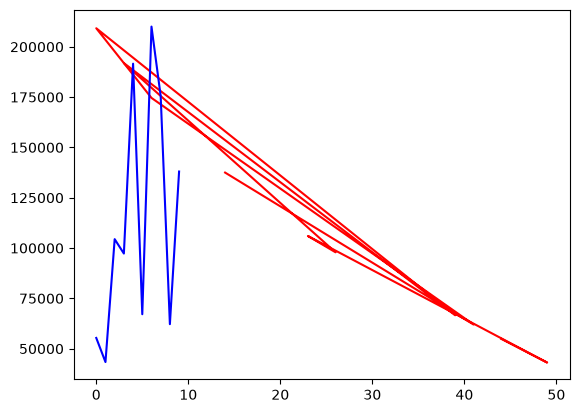

In [67]:
plt.plot(y_test, color="red")
plt.plot(y_pred, color="blue")